# 🧠 Brain Tumor MRI Classification — Google Colab (95%+ target)

**Model:** EfficientNetB0 (ImageNet pretrained) → 3-phase transfer learning  
**Data:** Kaggle *Brain Tumor MRI Dataset* (glioma / meningioma / notumor / pituitary)  
**Output:** `brain_tumor_effnet.weights.h5` + `class_names.json` → used by your local FastAPI + Streamlit app

### Colab setup (30 seconds)
1. **Runtime → Change runtime type → T4 GPU → Save**
2. Upload `archive.zip` (the Kaggle dataset zip) to your **Google Drive root** (`My Drive/archive.zip`) — *or skip this, the notebook will auto-download it from Kaggle if the zip isn't found.*
3. **Runtime → Run all**. Total time on a T4 GPU: roughly 15–25 minutes.

> Honest note: on this dataset, this recipe normally lands around **97–99%** test accuracy, but I can't promise an exact number. The notebook prints a clear PASS/FAIL against 95% and automatically runs an extra fine-tuning phase if validation accuracy is short.


## 1. Setup & GPU check

In [1]:
import os, sys, json, shutil, zipfile, random, warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers

SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)
gpus = tf.config.list_physical_devices("GPU")
print("GPU:", gpus if gpus else "NONE  ->  Runtime > Change runtime type > T4 GPU (training on CPU will be very slow)")

TensorFlow: 2.21.0
GPU: NONE  ->  Runtime > Change runtime type > T4 GPU (training on CPU will be very slow)


## 2. Config

In [3]:
# ---------------- CONFIG ----------------
IMG_SIZE       = (224, 224)
BATCH_SIZE     = 32
IMAGENET_WEIGHTS = "imagenet"   # keep "imagenet" on Colab
EPOCHS_HEAD    = 6              # phase 1: train classifier head only
EPOCHS_FINE    = 25             # phase 2: fine-tune top of backbone
EPOCHS_EXTRA   = 12             # phase 3: only runs automatically if val acc is still low
VAL_SPLIT      = 0.15
TARGET_ACC     = 0.95
ZIP_PATH       = "/content/drive/MyDrive/archive.zip"   # change if your zip is elsewhere
# ----------------------------------------
CLASS_NAMES = ["glioma", "meningioma", "notumor", "pituitary"]   # alphabetical = Keras folder order
NUM_CLASSES = len(CLASS_NAMES)

## 3. Get the dataset
Tries, in order: already-extracted data → your zip on Google Drive → direct download from Kaggle.

In [4]:
IN_COLAB = "google.colab" in sys.modules
WORK_DIR = "/content/dataset" if IN_COLAB else os.path.join(os.getcwd(), "dataset")

def find_root(base):
    if not os.path.isdir(base):
        return None
    for dirpath, dirnames, _ in os.walk(base):
        if "Training" in dirnames and "Testing" in dirnames:
            return dirpath
    return None

DATA_ROOT = find_root(WORK_DIR)

if DATA_ROOT is None and IN_COLAB:
    try:
        from google.colab import drive
        drive.mount("/content/drive")
    except Exception as e:
        print("Drive mount skipped:", e)

if DATA_ROOT is None:
    for cand in [ZIP_PATH, "/content/archive.zip", os.path.join(os.getcwd(), "archive.zip")]:
        if os.path.exists(cand):
            print("Found zip:", cand, "-> extracting...")
            os.makedirs(WORK_DIR, exist_ok=True)
            with zipfile.ZipFile(cand) as z:
                z.extractall(WORK_DIR)
            DATA_ROOT = find_root(WORK_DIR)
            break

if DATA_ROOT is None:
    print("Zip not found - downloading from Kaggle via kagglehub...")
    os.system(f"{sys.executable} -m pip install -q kagglehub")
    import kagglehub
    path = kagglehub.dataset_download("masoudnickparvar/brain-tumor-mri-dataset")
    DATA_ROOT = find_root(path)

assert DATA_ROOT is not None, "Dataset not found. Upload archive.zip to Google Drive root and re-run this cell."
TRAIN_DIR = os.path.join(DATA_ROOT, "Training")
TEST_DIR  = os.path.join(DATA_ROOT, "Testing")
print("DATA_ROOT:", DATA_ROOT)

rows = []
for split, d in [("Training", TRAIN_DIR), ("Testing", TEST_DIR)]:
    for c in CLASS_NAMES:
        rows.append((split, c, len(os.listdir(os.path.join(d, c)))))
df = pd.DataFrame(rows, columns=["split", "class", "images"])
display(df.pivot(index="class", columns="split", values="images"))


Zip not found - downloading from Kaggle via kagglehub...
DATA_ROOT: C:\Users\Muzammil A Muhammad\.cache\kagglehub\datasets\masoudnickparvar\brain-tumor-mri-dataset\versions\2


split,Testing,Training
class,,
glioma,400,1400
meningioma,400,1400
notumor,400,1400
pituitary,400,1400


## 4. Look at the data

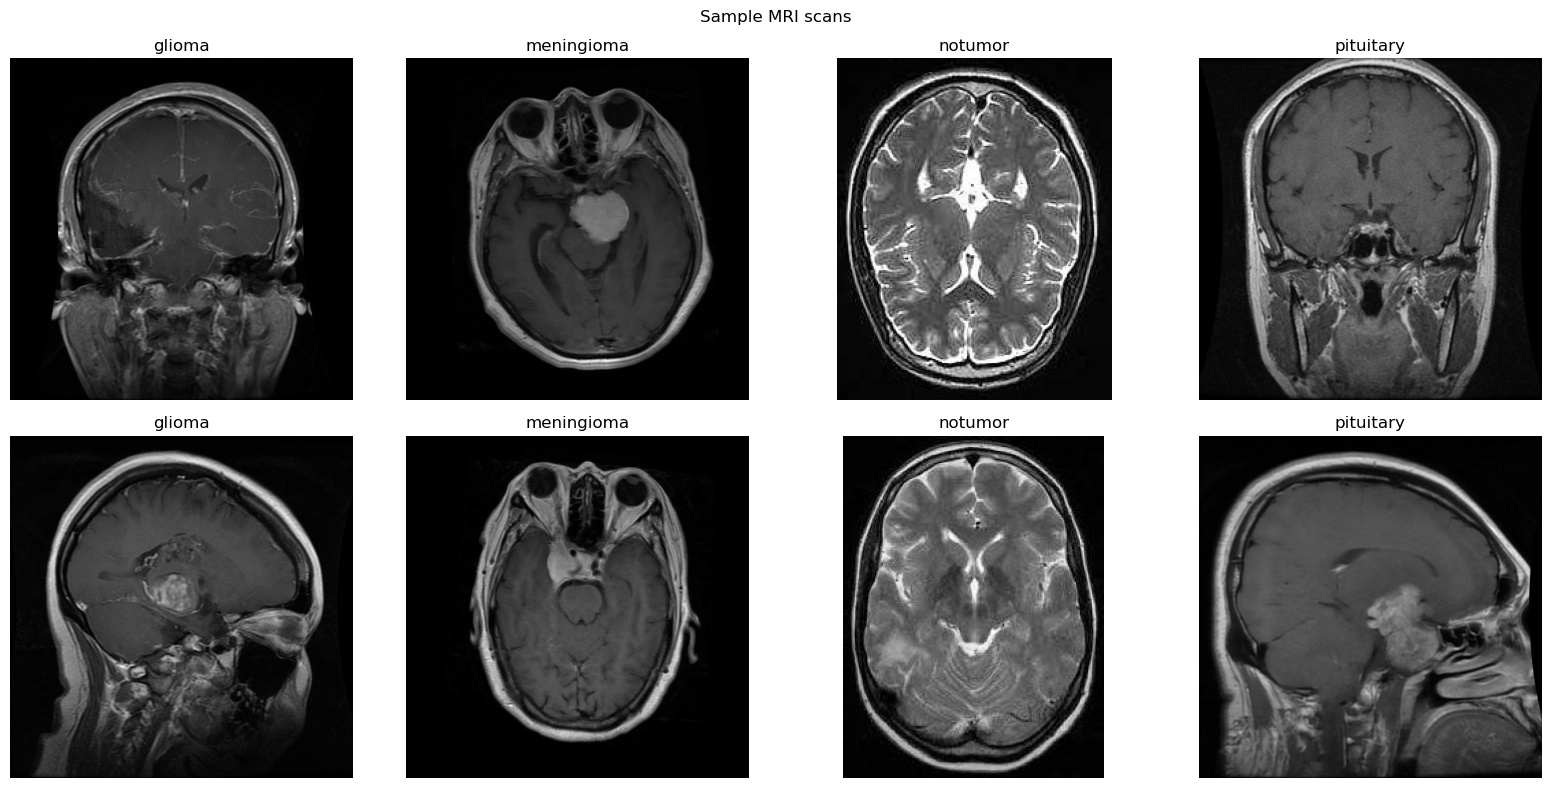

In [5]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for j, c in enumerate(CLASS_NAMES):
    files = sorted(os.listdir(os.path.join(TRAIN_DIR, c)))
    for i in range(2):
        img = plt.imread(os.path.join(TRAIN_DIR, c, files[i * 50]))
        axes[i][j].imshow(img, cmap="gray"); axes[i][j].set_title(c); axes[i][j].axis("off")
plt.suptitle("Sample MRI scans"); plt.tight_layout(); plt.show()

## 5. Input pipeline (tf.data)

- Images stay in **0-255** range — EfficientNet has its own normalisation built in (feeding 0-1 would hurt accuracy).
- Augmentation: small rotation / zoom / shift / contrast. **No horizontal flip** (left/right anatomy matters).
- Validation is carved out of `Training/`; the `Testing/` folder is touched **only once** at the end.

In [6]:
def make_ds(directory, subset=None, shuffle=False):
    return tf.keras.utils.image_dataset_from_directory(
        directory, labels="inferred", label_mode="categorical",
        class_names=CLASS_NAMES, color_mode="rgb", image_size=IMG_SIZE,
        batch_size=BATCH_SIZE, shuffle=shuffle, seed=SEED,
        validation_split=VAL_SPLIT if subset else None, subset=subset)

train_raw = make_ds(TRAIN_DIR, "training", shuffle=True)
val_ds    = make_ds(TRAIN_DIR, "validation")
test_ds   = make_ds(TEST_DIR)

augment = tf.keras.Sequential([
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.10),
    layers.RandomTranslation(0.05, 0.05),
    layers.RandomContrast(0.10),
], name="augment")

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_raw.map(lambda x, y: (augment(x, training=True), y), num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)
val_ds   = val_ds.prefetch(AUTOTUNE)
test_ds  = test_ds.prefetch(AUTOTUNE)

Found 5600 files belonging to 4 classes.
Using 4760 files for training.
Found 5600 files belonging to 4 classes.
Using 840 files for validation.
Found 1600 files belonging to 4 classes.


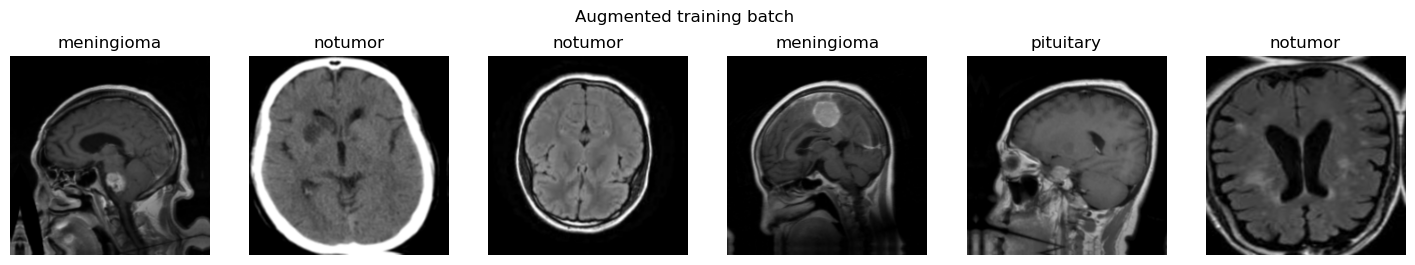

In [7]:
xb, yb = next(iter(train_ds))
fig, axes = plt.subplots(1, 6, figsize=(18, 3))
for i, ax in enumerate(axes):
    ax.imshow(xb[i].numpy().astype("uint8")); ax.set_title(CLASS_NAMES[int(tf.argmax(yb[i]))]); ax.axis("off")
plt.suptitle("Augmented training batch"); plt.show()

## 6. Model — EfficientNetB0 + custom head

In [8]:
def build_model(weights=IMAGENET_WEIGHTS):
    base = tf.keras.applications.EfficientNetB0(include_top=False, weights=weights, input_shape=(*IMG_SIZE, 3))
    base.trainable = False
    inputs = tf.keras.Input(shape=(*IMG_SIZE, 3))          # expects 0-255 pixels
    x = base(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)
    return tf.keras.Model(inputs, outputs, name="brain_tumor_effnet"), base

def compile_model(model, lr):
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.05),
        metrics=["accuracy"])

model, base = build_model()
compile_model(model, 1e-3)
print("Backbone params:", f"{base.count_params():,}", "| total params:", f"{model.count_params():,}")

Backbone params: 4,049,571 | total params: 4,383,655


## 7. Phase 1 — train the head (backbone frozen)

In [9]:
cb = [
    tf.keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=6, restore_best_weights=True, mode="max"),
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.3, patience=2, min_lr=1e-7),
]
h1 = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS_HEAD, callbacks=cb)

Epoch 1/6
149/149 ━━━━━━━━━━━━━━━━━━━━ 288s 2s/step - accuracy: 0.7739 - loss: 0.8442 - val_accuracy: 0.9952 - val_loss: 0.2596 - learning_rate: 0.0010
Epoch 2/6
149/149 ━━━━━━━━━━━━━━━━━━━━ 202s 1s/step - accuracy: 0.8317 - loss: 0.6548 - val_accuracy: 0.9929 - val_loss: 0.2605 - learning_rate: 0.0010
Epoch 3/6
149/149 ━━━━━━━━━━━━━━━━━━━━ 219s 1s/step - accuracy: 0.8817 - loss: 0.4891 - val_accuracy: 0.9952 - val_loss: 0.2745 - learning_rate: 3.0000e-04
Epoch 5/6
149/149 ━━━━━━━━━━━━━━━━━━━━ 252s 2s/step - accuracy: 0.8918 - loss: 0.4711 - val_accuracy: 0.9952 - val_loss: 0.2702 - learning_rate: 3.0000e-04
Epoch 6/6
149/149 ━━━━━━━━━━━━━━━━━━━━ 260s 2s/step - accuracy: 0.8971 - loss: 0.4591 - val_accuracy: 0.9952 - val_loss: 0.2685 - learning_rate: 9.0000e-05


## 8. Phase 2 — fine-tune the top of the backbone
BatchNorm layers stay frozen (standard best practice for fine-tuning EfficientNet).

In [10]:
def unfreeze(base, n_top):
    base.trainable = True
    for l in base.layers[:-n_top]:
        l.trainable = False
    for l in base.layers:
        if isinstance(l, layers.BatchNormalization):
            l.trainable = False
    print("Trainable backbone layers:", sum(l.trainable for l in base.layers), "/", len(base.layers))

unfreeze(base, 120)
compile_model(model, 1e-4)
h2 = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS_FINE, callbacks=cb)

Trainable backbone layers: 95 / 238
Epoch 1/25
149/149 ━━━━━━━━━━━━━━━━━━━━ 384s 2s/step - accuracy: 0.8508 - loss: 0.5866 - val_accuracy: 0.9893 - val_loss: 0.2734 - learning_rate: 1.0000e-04
Epoch 2/25
149/149 ━━━━━━━━━━━━━━━━━━━━ 29539s 200s/step - accuracy: 0.9042 - loss: 0.4648 - val_accuracy: 0.9810 - val_loss: 0.2910 - learning_rate: 1.0000e-04
Epoch 3/25
149/149 ━━━━━━━━━━━━━━━━━━━━ 416s 3s/step - accuracy: 0.9309 - loss: 0.4143 - val_accuracy: 0.9929 - val_loss: 0.2739 - learning_rate: 1.0000e-04
Epoch 4/25
149/149 ━━━━━━━━━━━━━━━━━━━━ 385s 3s/step - accuracy: 0.9645 - loss: 0.3330 - val_accuracy: 0.9988 - val_loss: 0.2975 - learning_rate: 9.0000e-06
Epoch 7/25
149/149 ━━━━━━━━━━━━━━━━━━━━ 341s 2s/step - accuracy: 0.9670 - loss: 0.3343 - val_accuracy: 0.9988 - val_loss: 0.3002 - learning_rate: 9.0000e-06
Epoch 8/25
149/149 ━━━━━━━━━━━━━━━━━━━━ 391s 3s/step - accuracy: 0.9653 - loss: 0.3334 - val_accuracy: 0.9988 - val_loss: 0.3019 - learning_rate: 2.7000e-06
Epoch 9/25
149/149

## 9. Phase 3 — automatic extra fine-tuning (only runs if validation accuracy is still below target)

In [11]:
val_loss, val_acc = model.evaluate(val_ds, verbose=0)
print(f"Validation accuracy after phase 2: {val_acc:.4f}")
h3 = None
if val_acc < 0.97:
    print("Below 97% -> running phase 3 (unfreeze whole backbone, very low LR)...")
    unfreeze(base, len(base.layers))
    compile_model(model, 2e-5)
    h3 = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS_EXTRA, callbacks=cb)
    val_loss, val_acc = model.evaluate(val_ds, verbose=0)
    print(f"Validation accuracy after phase 3: {val_acc:.4f}")
else:
    print("Validation accuracy is already high - skipping phase 3.")

Validation accuracy after phase 2: 0.9988
Validation accuracy is already high - skipping phase 3.


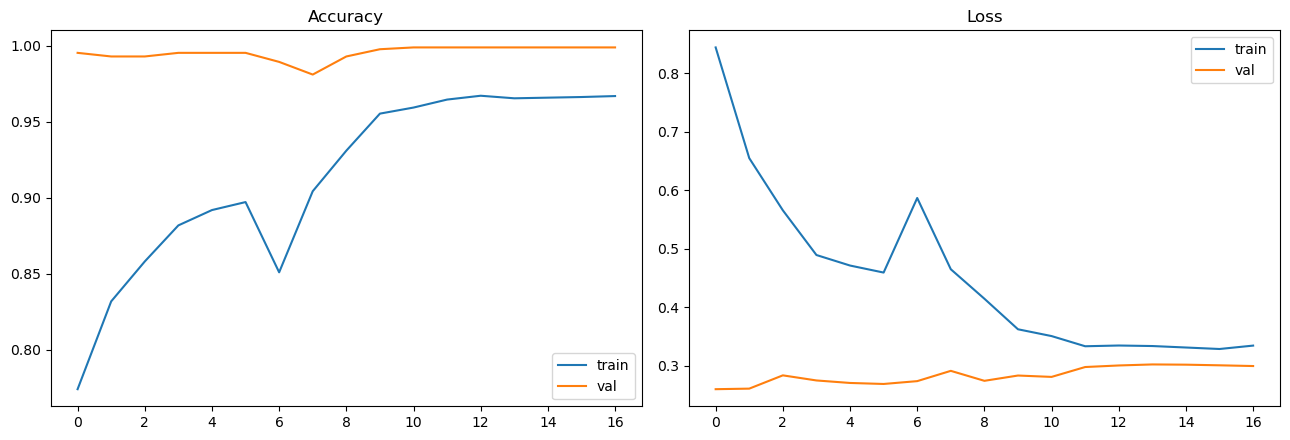

In [12]:
hists = [h for h in (h1, h2, h3) if h is not None]
acc  = sum([h.history["accuracy"] for h in hists], [])
vacc = sum([h.history["val_accuracy"] for h in hists], [])
loss = sum([h.history["loss"] for h in hists], [])
vloss= sum([h.history["val_loss"] for h in hists], [])
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
ax[0].plot(acc, label="train"); ax[0].plot(vacc, label="val"); ax[0].set_title("Accuracy"); ax[0].legend()
ax[1].plot(loss, label="train"); ax[1].plot(vloss, label="val"); ax[1].set_title("Loss"); ax[1].legend()
plt.tight_layout(); plt.show()

## 10. Final evaluation on the untouched Testing set

In [13]:
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize

y_true = np.concatenate([np.argmax(y.numpy(), axis=1) for _, y in test_ds])
probs  = model.predict(test_ds, verbose=0)
y_pred = np.argmax(probs, axis=1)
test_acc = float((y_true == y_pred).mean())

print(f"TEST ACCURACY: {test_acc:.4f}  ({test_acc*100:.2f}%)")
print("PASS: 95%+ target reached" if test_acc >= TARGET_ACC else "BELOW 95% - see the tips in the last cell")
print("\nPredicted-class counts (should be spread over all 4 classes):", dict(zip(CLASS_NAMES, np.bincount(y_pred, minlength=4))))
print()
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, digits=4))

TEST ACCURACY: 0.9181  (91.81%)
BELOW 95% - see the tips in the last cell

Predicted-class counts (should be spread over all 4 classes): {'glioma': np.int64(327), 'meningioma': np.int64(397), 'notumor': np.int64(429), 'pituitary': np.int64(447)}

              precision    recall  f1-score   support

      glioma     0.9786    0.8000    0.8803       400
  meningioma     0.8841    0.8775    0.8808       400
     notumor     0.9301    0.9975    0.9626       400
   pituitary     0.8926    0.9975    0.9421       400

    accuracy                         0.9181      1600
   macro avg     0.9214    0.9181    0.9165      1600
weighted avg     0.9214    0.9181    0.9165      1600



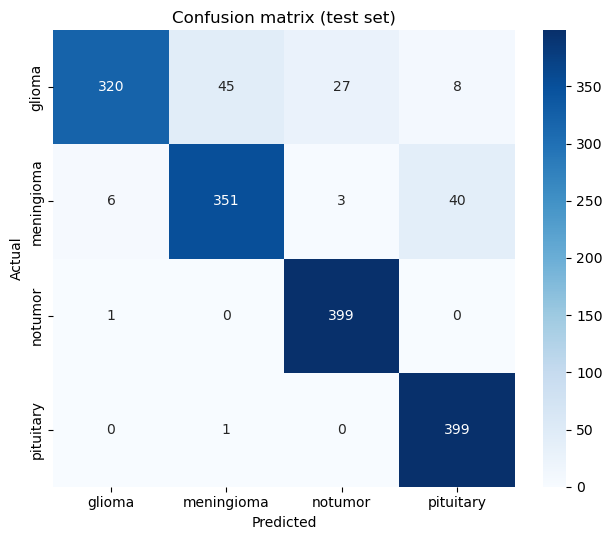

Per-class sensitivity / specificity (missing a tumour is the costly error):
  glioma      sensitivity=0.8000  specificity=0.9942
  meningioma  sensitivity=0.8775  specificity=0.9617
  notumor     sensitivity=0.9975  specificity=0.9750
  pituitary   sensitivity=0.9975  specificity=0.9600


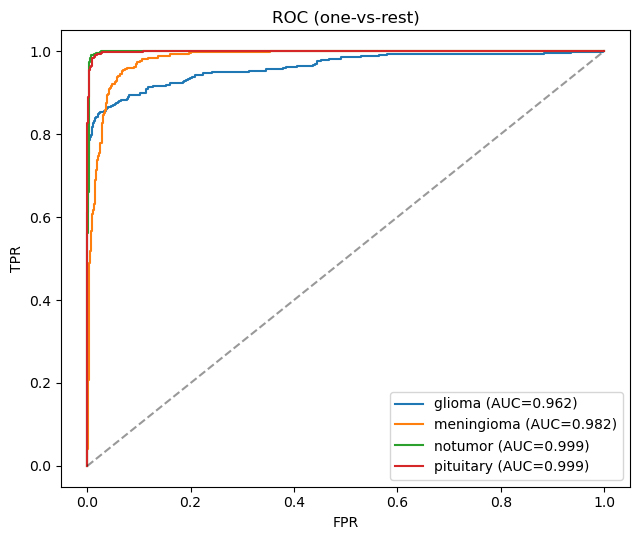

In [14]:
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6.5, 5.5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel("Predicted"); plt.ylabel("Actual"); plt.title("Confusion matrix (test set)"); plt.tight_layout(); plt.show()

print("Per-class sensitivity / specificity (missing a tumour is the costly error):")
for i, c in enumerate(CLASS_NAMES):
    tp = cm[i, i]; fn = cm[i].sum() - tp; fp = cm[:, i].sum() - tp; tn = cm.sum() - tp - fn - fp
    print(f"  {c:11s} sensitivity={tp/(tp+fn):.4f}  specificity={tn/(tn+fp):.4f}")

yb_ = label_binarize(y_true, classes=range(NUM_CLASSES))
plt.figure(figsize=(6.5, 5.5))
for i, c in enumerate(CLASS_NAMES):
    fpr, tpr, _ = roc_curve(yb_[:, i], probs[:, i]); plt.plot(fpr, tpr, label=f"{c} (AUC={auc(fpr, tpr):.3f})")
plt.plot([0, 1], [0, 1], "k--", alpha=.4); plt.legend(); plt.xlabel("FPR"); plt.ylabel("TPR"); plt.title("ROC (one-vs-rest)")
plt.tight_layout(); plt.show()

## 11. Grad-CAM — what the model looked at

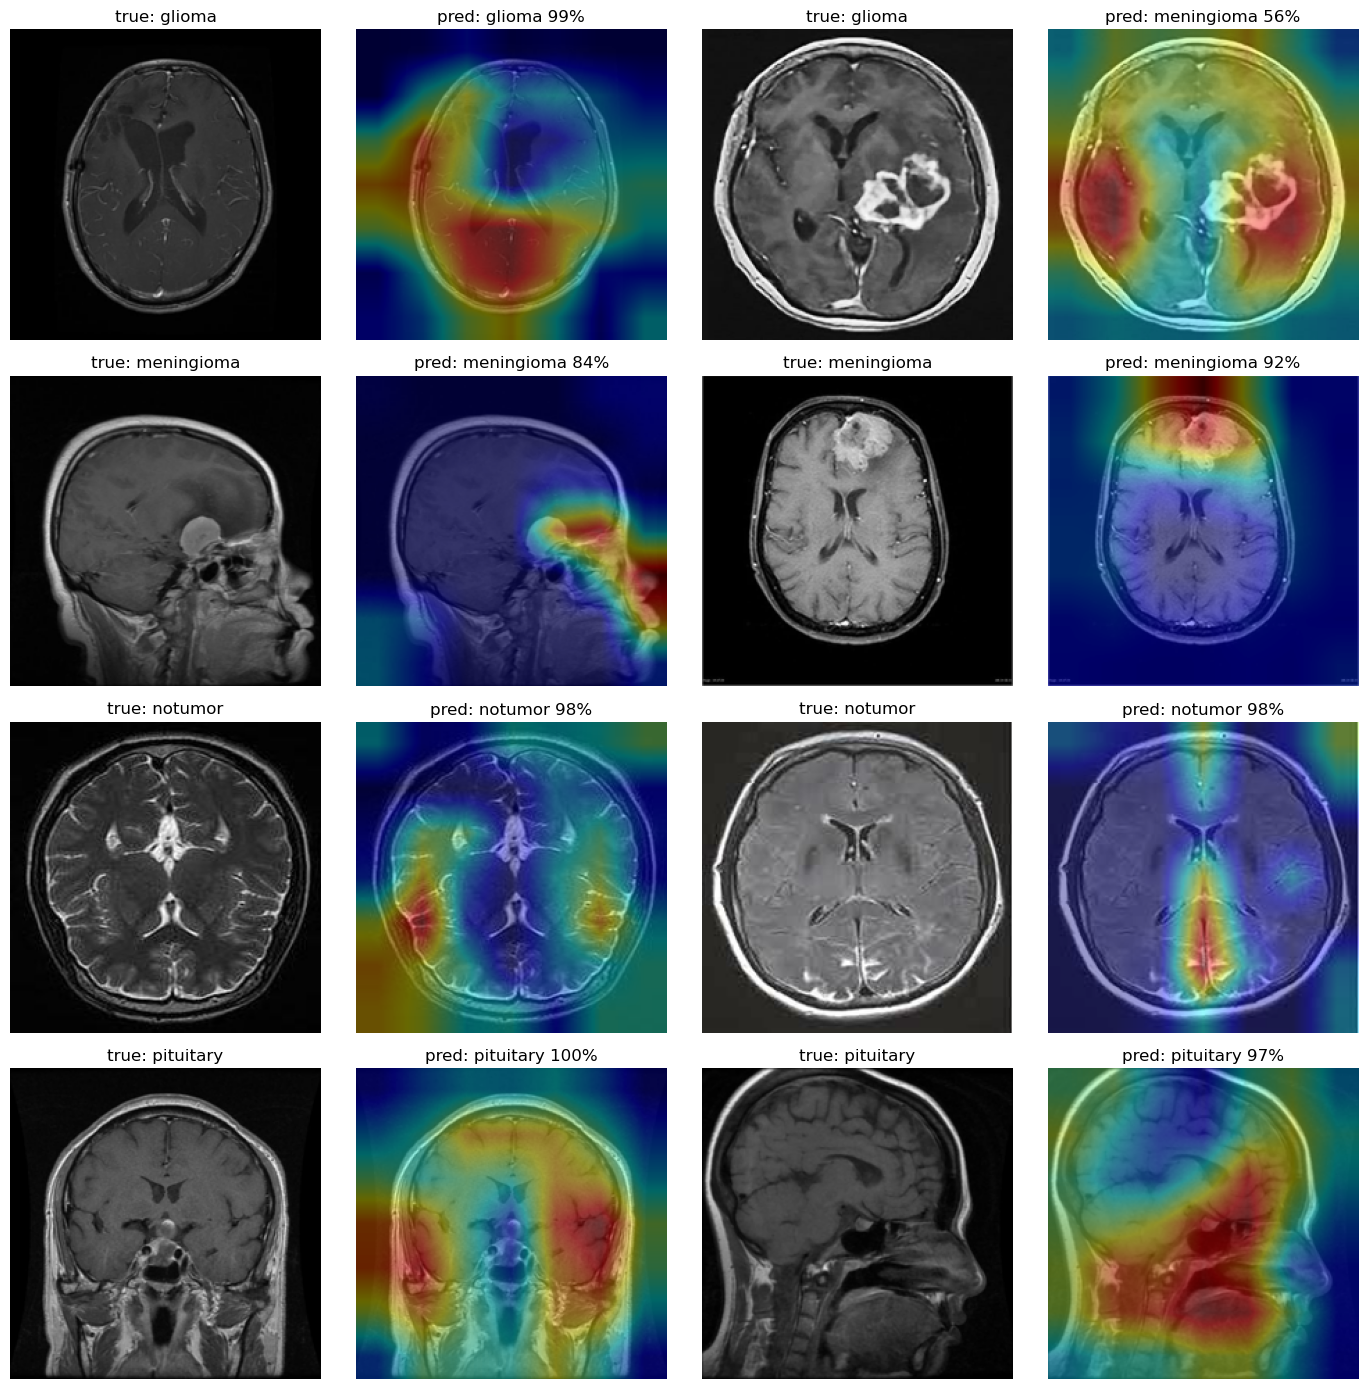

In [15]:
import cv2
from PIL import Image

def gradcam_heatmap(img_batch, model, base, pred_index=None):
    last_conv = [l for l in base.layers if isinstance(l, layers.Conv2D)][-1]
    grad_base = tf.keras.Model(base.input, [last_conv.output, base.output])
    head = model.layers[model.layers.index(base) + 1:]
    with tf.GradientTape() as tape:
        conv_out, feats = grad_base(img_batch)
        tape.watch(conv_out)
        x = feats
        for l in head:
            x = l(x)
        if pred_index is None:
            pred_index = int(tf.argmax(x[0]))
        score = x[:, pred_index]
    grads = tape.gradient(score, conv_out)
    w = tf.reduce_mean(grads, axis=(0, 1, 2))
    cam = tf.squeeze(conv_out[0] @ w[..., tf.newaxis])
    cam = tf.maximum(cam, 0) / (tf.reduce_max(cam) + 1e-8)
    return cam.numpy()

def overlay(rgb_uint8, cam, alpha=0.4):
    cam = cv2.resize(cam, (rgb_uint8.shape[1], rgb_uint8.shape[0]))
    color = cv2.cvtColor(cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET), cv2.COLOR_BGR2RGB)
    return cv2.addWeighted(rgb_uint8, 1 - alpha, color, alpha, 0)

fig, axes = plt.subplots(4, 4, figsize=(14, 14))
for r, c in enumerate(CLASS_NAMES):
    files = sorted(os.listdir(os.path.join(TEST_DIR, c)))
    for k, f in enumerate(random.sample(files, 2)):
        img = np.array(Image.open(os.path.join(TEST_DIR, c, f)).convert("RGB").resize(IMG_SIZE))
        batch = tf.convert_to_tensor(img[None].astype("float32"))
        p = model(batch, training=False).numpy()[0]; pi = int(p.argmax())
        cam = gradcam_heatmap(batch, model, base, pi)
        axes[r][2*k].imshow(img); axes[r][2*k].set_title(f"true: {c}"); axes[r][2*k].axis("off")
        axes[r][2*k+1].imshow(overlay(img, cam)); axes[r][2*k+1].set_title(f"pred: {CLASS_NAMES[pi]} {p[pi]:.0%}"); axes[r][2*k+1].axis("off")
plt.tight_layout(); plt.show()

## 12. Save the model for Streamlit app

In [16]:
OUT = "/content/brain_tumor_outputs" if IN_COLAB else os.path.join(os.getcwd(), "brain_tumor_outputs")
os.makedirs(OUT, exist_ok=True)
model.save_weights(os.path.join(OUT, "brain_tumor_effnet.weights.h5"))
model.save(os.path.join(OUT, "brain_tumor_effnet.keras"))
with open(os.path.join(OUT, "class_names.json"), "w") as f:
    json.dump(CLASS_NAMES, f)
print("Saved:", os.listdir(OUT))

if IN_COLAB:
    try:
        shutil.copytree(OUT, "/content/drive/MyDrive/brain_tumor_outputs", dirs_exist_ok=True)
        print("Backup copied to Google Drive -> My Drive/brain_tumor_outputs")
    except Exception as e:
        print("Drive backup skipped:", e)
    from google.colab import files
    files.download(os.path.join(OUT, "brain_tumor_effnet.weights.h5"))
    files.download(os.path.join(OUT, "class_names.json"))

Saved: ['brain_tumor_effnet.keras', 'brain_tumor_effnet.weights.h5', 'class_names.json']


## 13. What to do next

1. Put the two downloaded files into your local project's **`models/`** folder:
   - `models/brain_tumor_effnet.weights.h5`
   - `models/class_names.json`
2. Replace `api/main.py` and `app/streamlit_app.py` with the new versions.
3. Run `uvicorn api.main:app --port 8000` and `streamlit run app/streamlit_app.py`.

**If test accuracy came out below 95%:** re-run with `EPOCHS_FINE = 40` and `IMG_SIZE = (256, 256)` (also change it in the API), or send me the classification report + confusion matrix and I'll tune it.